# Chapter 3 - Data Cleaning and Exploratory Analysis

Chapter 1 covered how the data was fetched. This chapter covers what had to be done
to make it trustworthy, and what the cleaned dataset actually looks like.

The chapter has two parts:

- **Part A - cleaning at the source.** Almost all cleaning in this project happens
  inside the scraper (`app/controller/bot/bots/SUT_Music_bot.py`) as messages arrive,
  not as a batch pass afterwards. Part A reproduces that logic step by step and ends
  with the one piece of feature engineering that came out of the scraping stage: the
  `reaction_types` table, which converts raw emoji into a signed `(sentiment, strength)`
  signal.
- **Part B - the shape of the cleaned dataset.** Distributions, sparsity and coverage
  measured on the real derived data, and what each of those measurements implies for
  the recommendation engine in Chapter 4.

**On data sources.** Part A does not touch the database. It runs on a small synthetic
sample constructed in the notebook, which is enough to demonstrate every cleaning step
without requiring credentials or a 14,000-track dump. The functions themselves are
copied verbatim from the live scraper, so the behaviour shown is the real behaviour.
Part B uses real data: the derived artifacts committed under `engine_v2/model_params/`,
which are the exact inputs the deployed recommendation engine serves from.

## Pipeline

```mermaid
flowchart LR
    A["Raw Telegram message<br/>title + performer"] --> B["Clean performer<br/>strip brackets, handles, promo text"]
    B --> C["Split into artists<br/>ft / feat / vs / and / comma / slash"]
    C --> D["Normalise each name<br/>invisible chars, punctuation, blocklist"]
    D --> E{"Usable title?"}
    E -- no --> X["Dropped at the source"]
    E -- yes --> F["De-duplicate by (title, performer)"]
    F --> G["Tidy track-artist table"]
    G --> H["reaction_types<br/>sentiment + strength lookup"]
    H --> I["Weighted per-track score"]
```

In [1]:
import io
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 60)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

INK = "#334155"
ACCENT = "#4F46E5"
POSITIVE = "#15803D"
NEGATIVE = "#B91C1C"
MUTED = "#94A3B8"

## A.1 A representative raw sample

This is what a batch of `(title, performer)` pairs looks like before any cleaning:
bracketed promotional tags, channel handles, inconsistent whitespace, missing titles,
and one track uploaded twice (`msg_id` 10231 and 10240 are the same song).

In [2]:
raw_rows = [
    {"msg_id": 10231, "title": "Blinding Lights", "performer": "The Weeknd"},
    {"msg_id": 10232, "title": "", "performer": "[Prod. by Ghost Studio] Unknown Artist @sut_music_promo"},
    {"msg_id": 10233, "title": "Bohemian Rhapsody (Live Aid 1985 Remaster)",
     "performer": "Queen ft. Freddie Mercury Tribute \u2022 download @musicbot"},
    {"msg_id": 10234, "title": "Levitating", "performer": "Dua Lipa & DaBaby"},
    {"msg_id": 10235, "title": "Shape of You   ", "performer": "  Ed Sheeran  "},
    {"msg_id": 10236, "title": None, "performer": ""},
    {"msg_id": 10237, "title": "Peaches", "performer": "Justin Bieber feat. Daniel Caesar, Giveon"},
    {"msg_id": 10238, "title": "   ", "performer": "Some Random Uploader"},
    {"msg_id": 10239, "title": "Sunflower", "performer": "Post Malone / Swae Lee"},
    {"msg_id": 10240, "title": "Blinding Lights", "performer": "The Weeknd"},
    {"msg_id": 10241, "title": "Save Your Tears (Remix)",
     "performer": "The Weeknd ~ Ariana Grande [Official Audio] <HQ>"},
    {"msg_id": 10242, "title": "God's Plan", "performer": "Drake : ft. unknown vocalist - live version"},
    {"msg_id": 10243, "title": "Midnight City", "performer": "M83\u00ad"},
    {"msg_id": 10244, "title": "I Like You (A Happier Song) (feat. Doja Cat)", "performer": "Post Malone"},
]
raw_tracks = pd.DataFrame(raw_rows)
raw_tracks[["msg_id", "title", "performer"]]

,msg_id,title,performer
0,10231,Blinding Lights,The Weeknd
1,10232,,[Prod. by Ghost Studio] Unknown Artist @sut_music_promo
2,10233,Bohemian Rhapsody (Live Aid 1985 Remaster),Queen ft. Freddie Mercury Tribute • download @musicbot
3,10234,Levitating,Dua Lipa & DaBaby
4,10235,Shape of You,Ed Sheeran
5,10236,NaN,
6,10237,Peaches,"Justin Bieber feat. Daniel Caesar, Giveon"
7,10238,,Some Random Uploader
8,10239,Sunflower,Post Malone / Swae Lee
9,10240,Blinding Lights,The Weeknd


## A.2 Performer cleaning and artist extraction

Both functions below are copied verbatim from `SUT_Music_bot`. `_get_clean_performer`
removes bracketed content first, so that handles and bullet separators hidden inside
brackets cannot corrupt the split that follows. `_extract_artists` then breaks the
remaining string on the delimiters uploaders actually use.

In [3]:
def get_clean_performer(raw_performer_str: str) -> str:
    """Verbatim port of SUT_Music_bot._get_clean_performer."""
    if not raw_performer_str:
        return ""
    brackets_pattern = r'(\[.*?\]|\(.*?\)|\{.*?\}|<.*?>)'
    cleaned = re.sub(brackets_pattern, '', raw_performer_str)
    cleaned = re.split(r'(?:\u2022|@)', cleaned)[0]
    return " ".join(cleaned.split()).strip()


def extract_artists(clean_performer_str: str) -> list:
    """Verbatim port of SUT_Music_bot._extract_artists."""
    if not clean_performer_str:
        return []
    delimiters_pattern = r'(?:[~:+,&\-/|\\]+|\bfeat(?:uring)?\b|\bft\b|\bvs\b)'
    possible_artists = re.split(delimiters_pattern, clean_performer_str, flags=re.IGNORECASE)
    return [a.strip() for a in possible_artists if a.strip()]


raw_tracks["clean_title"] = raw_tracks["title"].apply(
    lambda t: " ".join(str(t).split()).strip() if pd.notna(t) else ""
)
raw_tracks["clean_performer"] = raw_tracks["performer"].apply(get_clean_performer)
raw_tracks["artist_list_raw"] = raw_tracks["clean_performer"].apply(extract_artists)

raw_tracks[["msg_id", "clean_performer", "artist_list_raw"]]

,msg_id,clean_performer,artist_list_raw
0,10231,The Weeknd,[The Weeknd]
1,10232,Unknown Artist,[Unknown Artist]
2,10233,Queen ft. Freddie Mercury Tribute,"[Queen, . Freddie Mercury Tribute]"
3,10234,Dua Lipa & DaBaby,"[Dua Lipa, DaBaby]"
4,10235,Ed Sheeran,[Ed Sheeran]
5,10236,,[]
6,10237,"Justin Bieber feat. Daniel Caesar, Giveon","[Justin Bieber, . Daniel Caesar, Giveon]"
7,10238,Some Random Uploader,[Some Random Uploader]
8,10239,Post Malone / Swae Lee,"[Post Malone, Swae Lee]"
9,10240,The Weeknd,[The Weeknd]


The split is a heuristic, and it leaves artifacts. Because `ft`, `feat` and `featuring`
are matched as words, the trailing period in `ft.` and `feat.` survives into the next
name:

In [4]:
leftover = raw_tracks[raw_tracks["artist_list_raw"].apply(
    lambda names: any(name.startswith(".") for name in names)
)]
print(f"rows carrying leftover punctuation: {len(leftover)} of {len(raw_tracks)}")
leftover[["msg_id", "clean_performer", "artist_list_raw"]]

rows carrying leftover punctuation: 3 of 14


,msg_id,clean_performer,artist_list_raw
2,10233,Queen ft. Freddie Mercury Tribute,"[Queen, . Freddie Mercury Tribute]"
6,10237,"Justin Bieber feat. Daniel Caesar, Giveon","[Justin Bieber, . Daniel Caesar, Giveon]"
11,10242,Drake : ft. unknown vocalist - live version,"[Drake, . unknown vocalist, live version]"


## A.3 Name normalisation

The artifact above is no longer a known issue: the scraper now runs every split name
through a normalisation pass before it reaches the database. Beyond stripping stray
punctuation, that pass removes invisible Unicode characters, rejects an exact-match
blocklist of words that are not artist names, rejects bare domain names, and
de-duplicates case-insensitively within a single track.

Invisible characters matter more than they sound. A soft hyphen or zero-width space
pasted into a name is not visible to anyone, but it makes two identical-looking names
compare unequal, which silently creates a duplicate artist row.

In [5]:
def strip_invisible_chars(text: str) -> str:
    """Verbatim port of SUT_Music_bot._strip_invisible_chars.

    Unicode format (Cf) and control (Cc) characters - soft hyphens, zero-width
    spaces, byte-order marks, bidi marks - are copy-paste noise rather than
    part of a name.
    """
    return "".join(ch for ch in text if unicodedata.category(ch) not in ("Cf", "Cc"))


ARTIST_NAME_BLOCKLIST = {
    "live", "remix", "cover", "acoustic", "instrumental", "official",
    "audio", "video", "unknown", "unknown artist", "various artists",
    "va", "original mix", "explicit", "clean", "official audio",
    "official video", "hq", "prod", "prod by", "n/a", "na",
}
DOMAIN_LIKE_PATTERN = re.compile(
    r'^[a-z0-9-]+\.(com|net|org|io|co|tv|me|cc|info|biz|ru|xyz|ir|app|gg|link|to)$',
    re.IGNORECASE,
)


def normalize_artist_name(raw_name: str):
    """Verbatim port of SUT_Music_bot._normalize_artist_name.

    Returns None when the string is not usable as an artist name.
    """
    if not raw_name:
        return None
    name = strip_invisible_chars(raw_name)
    name = re.sub(r'(\[.*?\]|\(.*?\)|\{.*?\}|<.*?>)', '', name)
    name = name.strip(" \t\r\n.,;:!?-_'\"|/\\")
    name = " ".join(name.split())
    if not name:
        return None
    if name.lower() in ARTIST_NAME_BLOCKLIST:
        return None
    if DOMAIN_LIKE_PATTERN.match(name):
        return None
    if not re.search(r'\w', name, flags=re.UNICODE):
        return None
    return name


def clean_artist_names(raw_names: list) -> list:
    """Verbatim port of SUT_Music_bot._clean_artist_names."""
    cleaned, seen = [], set()
    for raw in raw_names:
        name = normalize_artist_name(raw)
        if not name:
            continue
        key = name.lower()
        if key in seen:
            continue
        seen.add(key)
        cleaned.append(name)
    return cleaned


raw_tracks["artist_list"] = raw_tracks["artist_list_raw"].apply(clean_artist_names)
raw_tracks[["msg_id", "artist_list_raw", "artist_list"]]

,msg_id,artist_list_raw,artist_list
0,10231,[The Weeknd],[The Weeknd]
1,10232,[Unknown Artist],[]
2,10233,"[Queen, . Freddie Mercury Tribute]","[Queen, Freddie Mercury Tribute]"
3,10234,"[Dua Lipa, DaBaby]","[Dua Lipa, DaBaby]"
4,10235,[Ed Sheeran],[Ed Sheeran]
5,10236,[],[]
6,10237,"[Justin Bieber, . Daniel Caesar, Giveon]","[Justin Bieber, Daniel Caesar, Giveon]"
7,10238,[Some Random Uploader],[Some Random Uploader]
8,10239,"[Post Malone, Swae Lee]","[Post Malone, Swae Lee]"
9,10240,[The Weeknd],[The Weeknd]


Five classes of problem are addressed by that single pass. Each is verified below
rather than asserted - including one that is only partly solved.

In [6]:
checks = [
    ("leading punctuation from 'ft.' / 'feat.'",
     clean_artist_names(["Queen", ". Freddie Mercury Tribute"])),
    ("invisible soft hyphen inside a name",
     [repr(n) for n in clean_artist_names(["M83\u00ad"])]),
    ("blocklisted words (exact match)",
     clean_artist_names(["Drake", ". unknown vocalist", "live version", "remix"])),
    ("bare domain names",
     clean_artist_names(["Fa.Com", "Real Artist"])),
    ("case-insensitive duplicates on one track",
     clean_artist_names(["Ed Sheeran", "ED SHEERAN", "ed sheeran"])),
]
for label, result in checks:
    print(f"{label:45} -> {result}")

leading punctuation from 'ft.' / 'feat.'      -> ['Queen', 'Freddie Mercury Tribute']
invisible soft hyphen inside a name           -> ["'M83'"]
blocklisted words (exact match)               -> ['Drake', 'unknown vocalist', 'live version']
bare domain names                             -> ['Real Artist']
case-insensitive duplicates on one track      -> ['Ed Sheeran']


Four of the five are fully handled. The blocklist is the exception: it matches whole
strings, so `remix` is rejected but `live version` and `unknown vocalist` are not, and
both survive into the artists table as if they were real performers. Widening it to
match on a per-word basis would risk rejecting legitimate names containing those words,
so the current behaviour is a deliberate trade - but it does mean the tail of the artist
distribution still contains a small amount of junk, which the next section shows.

## A.4 Featured artists credited in the title

A separate real defect: some uploaders put the featured credit in the title rather than
the performer tag, for example `title="I Like You (A Happier Song) (feat. Doja Cat)"`
with `performer="Post Malone"`. Because extraction only ever read the performer string,
those collaborators never reached the artists table at all. The scraper now scans the
title as well.

In [7]:
FEATURE_IN_TITLE_PATTERN = re.compile(
    r'[\(\[]\s*(?:feat(?:uring)?|ft)\.?\s+([^)\]]+)[\)\]]', re.IGNORECASE
)


def extract_featured_artists_from_title(title: str):
    """Verbatim port of SUT_Music_bot._extract_featured_artists_from_title."""
    if not title:
        return title, []
    names = []

    def _collect(match):
        names.extend(extract_artists(match.group(1)))
        return ""

    cleaned_title = FEATURE_IN_TITLE_PATTERN.sub(_collect, title)
    cleaned_title = " ".join(cleaned_title.split()).strip()
    return (cleaned_title or title), names


examples = [
    "I Like You (A Happier Song) (feat. Doja Cat)",
    "Duskus - Open My Eyes (ft. ANUKA)",
    "Running with the Wolves (WolfWalkers Version)",
]
for title in examples:
    cleaned, found = extract_featured_artists_from_title(title)
    print(f"{title!r:50} -> title={cleaned!r:42} featured={found}")

'I Like You (A Happier Song) (feat. Doja Cat)'     -> title='I Like You (A Happier Song)'              featured=['Doja Cat']
'Duskus - Open My Eyes (ft. ANUKA)'                -> title='Duskus - Open My Eyes'                    featured=['ANUKA']
'Running with the Wolves (WolfWalkers Version)'    -> title='Running with the Wolves (WolfWalkers Version)' featured=[]


## A.5 Dropping tracks with no usable title

A track whose title is empty, missing or whitespace-only never enters the database.
This is enforced at write time rather than cleaned up afterwards, which is what keeps
the table clean by construction.

In [8]:
has_title = raw_tracks["clean_title"].str.len() > 0
dropped = raw_tracks[~has_title]
named_tracks = raw_tracks[has_title].reset_index(drop=True)

print(f"{len(raw_tracks)} rows in -> {len(named_tracks)} kept, {len(dropped)} dropped")
dropped[["msg_id", "title", "performer"]]

14 rows in -> 11 kept, 3 dropped


,msg_id,title,performer
1,10232,,[Prod. by Ghost Studio] Unknown Artist @sut_music_promo
5,10236,NaN,
7,10238,,Some Random Uploader


## A.6 De-duplication by `(title, performer)`

A re-share does not create a second row. The existing track keeps its identity and the
new uploader is appended to its `uploaded_by` list, which is what makes "uploaded by"
a meaningful multi-user signal later - the recommendation engine treats an upload as a
strong positive for that track's artist.

In [9]:
named_tracks["dedup_key"] = (
    named_tracks["clean_title"].str.lower() + "||" + named_tracks["clean_performer"].str.lower()
)
duplicates = named_tracks.duplicated(subset="dedup_key", keep="first").sum()
print(f"re-shared tracks collapsed: {duplicates}")

uploaded_by = named_tracks.groupby("dedup_key")["msg_id"].apply(list)
tracks_clean = named_tracks.drop_duplicates(subset="dedup_key", keep="first").copy()
tracks_clean["uploaded_by_msg_ids"] = tracks_clean["dedup_key"].map(uploaded_by)

tracks_clean[["clean_title", "clean_performer", "uploaded_by_msg_ids"]]

re-shared tracks collapsed: 1


,clean_title,clean_performer,uploaded_by_msg_ids
0,Blinding Lights,The Weeknd,"[10231, 10240]"
1,Bohemian Rhapsody (Live Aid 1985 Remaster),Queen ft. Freddie Mercury Tribute,[10233]
2,Levitating,Dua Lipa & DaBaby,[10234]
3,Shape of You,Ed Sheeran,[10235]
4,Peaches,"Justin Bieber feat. Daniel Caesar, Giveon",[10237]
5,Sunflower,Post Malone / Swae Lee,[10239]
7,Save Your Tears (Remix),The Weeknd ~ Ariana Grande,[10241]
8,God's Plan,Drake : ft. unknown vocalist - live version,[10242]
9,Midnight City,M83­,[10243]
10,I Like You (A Happier Song) (feat. Doja Cat),Post Malone,[10244]


## A.7 The tidy track-artist table

One row per `(track, artist)` pair. This is the shape everything downstream consumes:
artist pages, per-artist reaction rollups, and the user-artist matrix the recommendation
engine is built on.

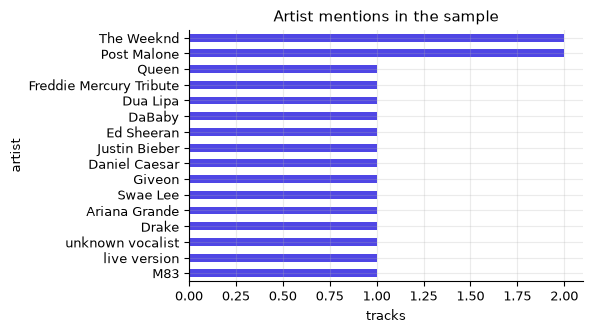

10 tracks -> 18 track-artist pairs, 16 distinct artists


In [10]:
artists_tidy = (
    tracks_clean.explode("artist_list")
    .rename(columns={"artist_list": "artist"})
    .dropna(subset=["artist"])
)
artists_tidy = artists_tidy[artists_tidy["artist"].str.len() > 0]

counts = artists_tidy["artist"].value_counts()
fig, ax = plt.subplots(figsize=(6, 3.4))
counts.plot(kind="barh", ax=ax, color=ACCENT)
ax.set_title("Artist mentions in the sample")
ax.set_xlabel("tracks")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"{len(tracks_clean)} tracks -> {len(artists_tidy)} track-artist pairs, "
      f"{artists_tidy['artist'].nunique()} distinct artists")

`unknown vocalist` and `live version` are both in that chart, ranked alongside real
performers. Both come from the single string `"Drake : ft. unknown vocalist - live
version"`, and both survive A.3 for the reason given there: the blocklist matches whole
strings only. This is the residual error rate of a regex-based approach, and the honest
conclusion is that the tail of this distribution needs a periodic manual review on the
real data - it is small, but it is not empty.

## A.8 Feature engineering: the `reaction_types` table

This is the one substantive piece of feature engineering from the scraping stage.
Telegram gives a reaction as nothing more than an emoji. On its own that is not a
feature, so every reaction the group uses was hand-tagged with three fields:

| field | meaning |
|---|---|
| `sentiment` | `like` / `neutral` / `dislike` - the coarse bucket |
| `strength` | signed float, roughly -5 to +5 - how much of that sentiment it carries |
| `description` | short gloss on what the emoji is being used to say |

This is what turns "this track received 40 reactions" into a weighted quantity. Forty
thumbs-up (+3) is a materially different signal from forty mind-blown (+5) or forty
thumbs-down (-4).

The table below is the real production table, not a sample. It has itself been through
a cleanup pass: the original contained visual duplicates that differed only by an
invisible variation selector, two plain-word placeholders instead of emoji, and one
genuine disagreement between two rows for the same emoji. The curated result is 53
unique rows.

In [11]:
reaction_types_csv = """id,emoji,sentiment,strength,description
1,\U0001F525,like,4.5,Fire / Viral Hit
2,\U0001F4AF,like,4.5,Perfect / Masterpiece
3,\U0001F970,like,4,Heart-warming
4,\U0001F389,like,4,Party / Dance Vibe
5,⚡,like,2,Electrifying
6,\U0001F44D,like,3,Solid Track / Approval
7,\U0001F44F,like,2.1,Well Produced / Applause
8,\U0001F91D,like,3,Relatable Vibe
9,\U0001F37E,like,5,Celebration Pop
10,\U0001F48B,like,5,Seductive / Smooth Vibe
11,\U0001F47E,like,2,Synthwave / Gaming Vibe
12,\U0001F34C,dislike,-4,Fun / Quirky Track
13,\U0001F353,like,3,Sweet / Acoustic Vibe
14,\U0001F192,like,3.5,Trendy / Cool Track
15,\U0001F485,like,3.5,Sassy / Confident Anthems
16,\U0001F62D,like,4.5,Deeply Moving / Beautifully Sad
17,\U0001F631,like,4,Mind-blowing Drop / Shocking Twist
18,\U0001F622,like,4,Melancholic / Nostalgic Melodies
19,\U0001F494,like,3.5,Heartbreak Anthem / Deep Lyrics
20,\U0001F610,neutral,-1,Unremarkable / Plain Track
21,\U0001F440,dislike,-2,Intriguing / Hidden Gem
22,\U0001F47B,like,2.5,Spooky / Electro-Goth Beat
23,❤,like,3.5,Standard Like
24,❤‍\U0001F525,like,5,Warm Interest
25,\U0001F923,like,2,Funny / Satirical Lyrics
26,\U0001F498,like,3.5,Catchy Love Song
27,\U0001F54A,like,4,Calm / Ambient Outro
28,\U0001F44C,like,3.5,Decent / Acceptable Mix
29,\U0001F92F,like,5,Insane Production / Complex Drop
30,\U0001F48A,neutral,2,Trippy / Psychedelic Sound
31,\U0001F937‍♂,neutral,-1.5,Undecided Response
32,\U0001F385,like,2.5,Christmas / Nostalgic Track
33,\U0001F31A,dislike,-3,Dark / Underground Vibe
34,\U0001FAE1,neutral,2,Respect to a Classic Track
35,\U0001F64F,like,2.5,Soulful / Spiritual Melodies
36,\U0001F60D,like,2.5,Highly Captivating Hook
37,\U0001F433,neutral,-2,Deep / Low-Frequency Bass
38,\U0001F971,dislike,-4,Boring / Derivative Track
39,\U0001F634,dislike,-3.5,Tiring / Low-energy Skater
40,\U0001F44E,dislike,-4,Bad Track / Thumbs Down
41,\U0001F649,dislike,-4.5,Terrible Audio / Ear Hurting
42,\U0001F648,neutral,0.5,Bad Performance / Can't Watch
43,\U0001F974,dislike,-5,Disorienting / Awful Mix
44,\U0001F92E,dislike,-5,Hated Everything About It
45,\U0001F4A9,dislike,-5,Garbage Quality / Worst Track
46,\U0001F601,like,2.5,Genuine Smile / Happy Vibe
47,\U0001F917,like,4,Wholesome / Feel-good Track
48,✍,like,2.5,Lyrically Strong / Poetic
49,\U0001F5FF,neutral,1,Cultured / Classic Reference
50,\U0001F32D,dislike,-2,Cheesy / Overly Obvious
51,CustomEmoji,neutral,0,
52,\U0001F60E,like,3,Cool / Stylish Production
53,\U0001F913,like,2,Nerdy / Intellectual Appeal
"""

reaction_types = (
    pd.read_csv(io.StringIO(reaction_types_csv), keep_default_na=False)
    .sort_values("id")
    .reset_index(drop=True)
)
print(f"{len(reaction_types)} reaction types, {reaction_types['emoji'].nunique()} distinct emoji")
reaction_types.head(8)

53 reaction types, 53 distinct emoji


,id,emoji,sentiment,strength,description
0,1,🔥,like,4.5,Fire / Viral Hit
1,2,💯,like,4.5,Perfect / Masterpiece
2,3,🥰,like,4.0,Heart-warming
3,4,🎉,like,4.0,Party / Dance Vibe
4,5,⚡,like,2.0,Electrifying
5,6,👍,like,3.0,Solid Track / Approval
6,7,👏,like,2.1,Well Produced / Applause
7,8,🤝,like,3.0,Relatable Vibe


### Distribution of sentiment and strength

Two things stand out. The table is heavily skewed towards `like` - 34 of 53 rows - which
reflects how the group actually reacts rather than a design choice. And the strength
scale is not symmetric around zero within each bucket: likes cluster tightly near +3.5,
dislikes near -4, while `neutral` sits close to zero on average but has the widest
spread of the three. That is the correct behaviour for a neutral bucket: it carries
signal, just not a consistent direction.

           count  mean   std  min   50%  max
sentiment                                   
dislike     11.0 -3.82  1.10 -5.0 -4.00 -2.0
like        34.0  3.40  0.97  2.0  3.50  5.0
neutral      8.0  0.12  1.53 -2.0  0.25  2.0


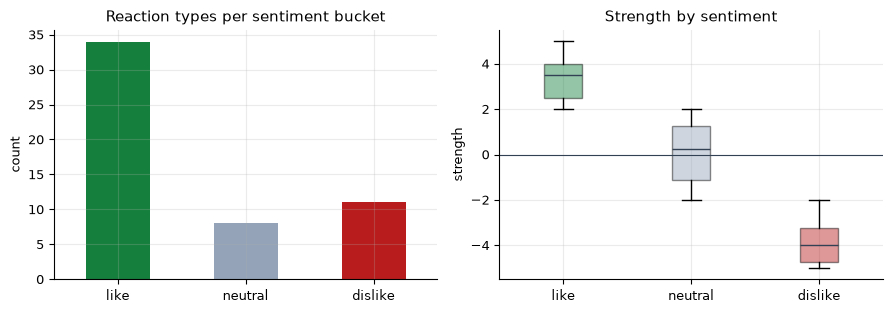

In [12]:
summary = reaction_types.groupby("sentiment")["strength"].describe().round(2)
print(summary[["count", "mean", "std", "min", "50%", "max"]])

order = ["like", "neutral", "dislike"]
colours = {"like": POSITIVE, "neutral": MUTED, "dislike": NEGATIVE}

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
reaction_types["sentiment"].value_counts().reindex(order).plot(
    kind="bar", ax=axes[0], color=[colours[s] for s in order]
)
axes[0].set_title("Reaction types per sentiment bucket")
axes[0].set_ylabel("count")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

data = [reaction_types.loc[reaction_types["sentiment"] == s, "strength"] for s in order]
box = axes[1].boxplot(data, tick_labels=order, patch_artist=True, medianprops={"color": INK})
for patch, sentiment in zip(box["boxes"], order):
    patch.set_facecolor(colours[sentiment])
    patch.set_alpha(0.45)
axes[1].axhline(0, color=INK, linewidth=0.8)
axes[1].set_title("Strength by sentiment")
axes[1].set_ylabel("strength")
plt.tight_layout()
plt.show()

One row is worth flagging as a data-quality issue rather than a design decision: three
entries are tagged `dislike` while describing something positive - id 12 (banana,
"Fun / Quirky Track", -4), id 21 (eyes, "Intriguing / Hidden Gem", -2) and id 33
("Dark / Underground Vibe", -3). The description and the sign disagree. Since the
recommendation engine reads only the numeric strength, these three emoji currently
subtract from a track's score while the label says they should add to it.

In [13]:
mismatch = reaction_types[
    (reaction_types["sentiment"] == "dislike")
    & reaction_types["description"].str.contains(
        "Fun|Intriguing|Hidden Gem|Vibe", case=False, regex=True
    )
]
mismatch[["id", "emoji", "sentiment", "strength", "description"]]

,id,emoji,sentiment,strength,description
11,12,🍌,dislike,-4.0,Fun / Quirky Track
20,21,👀,dislike,-2.0,Intriguing / Hidden Gem
32,33,🌚,dislike,-3.0,Dark / Underground Vibe


## A.9 Putting it together: weighted per-track score

A self-contained demonstration of why the table exists. Joining reactions against
`reaction_types` and reducing each track to one weighted number is the operation the
recommendation engine performs at scale - it is how a stream of emoji becomes a
user-track interaction matrix.

                 total_strength  mean_strength  reactions
track                                                    
Blinding Lights            12.0           4.00          3
God's Plan                 -3.5          -1.17          3
Levitating                 -3.0          -1.50          2


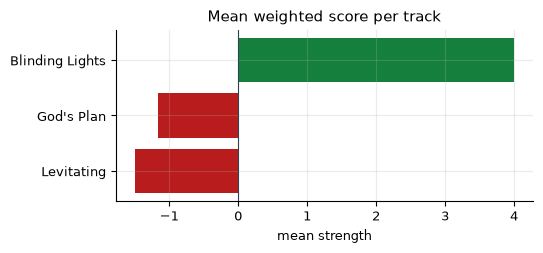

In [14]:
sample_reactions = pd.DataFrame([
    {"track": "Blinding Lights", "reaction_id": 1},   # fire, like, +4.5
    {"track": "Blinding Lights", "reaction_id": 2},   # 100, like, +4.5
    {"track": "Blinding Lights", "reaction_id": 6},   # thumbs up, like, +3
    {"track": "God's Plan", "reaction_id": 12},       # banana, dislike, -4
    {"track": "God's Plan", "reaction_id": 40},       # thumbs down, dislike, -4
    {"track": "God's Plan", "reaction_id": 1},        # fire, like, +4.5
    {"track": "Levitating", "reaction_id": 20},       # neutral face, -1
    {"track": "Levitating", "reaction_id": 37},       # whale, neutral, -2
])

scored = sample_reactions.merge(
    reaction_types[["id", "strength", "sentiment"]], left_on="reaction_id", right_on="id"
)
track_scores = (
    scored.groupby("track")["strength"]
    .agg(total_strength="sum", mean_strength="mean", reactions="count")
    .sort_values("mean_strength", ascending=False)
)
print(track_scores.round(2))

fig, ax = plt.subplots(figsize=(5.5, 2.6))
bars = track_scores["mean_strength"]
ax.barh(bars.index, bars.values, color=[POSITIVE if v >= 0 else NEGATIVE for v in bars])
ax.axvline(0, color=INK, linewidth=0.8)
ax.set_title("Mean weighted score per track")
ax.set_xlabel("mean strength")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Note what the mean hides. "God's Plan" and "Levitating" score similarly on the mean
(-1.17 against -1.50), but they are not similar tracks: the first is polarising, with
one strong positive and two strong negatives, while the second is simply unremarkable.
Chapter 4's engine sidesteps this by discarding non-positive reactions entirely and
counting only the positives, which is a defensible simplification but throws away the
distinction visible here.

---

# Part B - The cleaned dataset in aggregate

Part A worked on a synthetic sample so the mechanics stayed visible. This part measures
the real thing.

The raw CSVs are not in the repository, but the derived artifacts are: everything under
`engine_v2/model_params/` was produced by the cleaning and training pipeline and is what
the deployed recommendation engine actually serves from. Three of those files are plain
Python objects that can be read with no extra dependencies, and together they describe
the full cleaned catalogue:

| file | contents |
|---|---|
| `track_to_artist.pkl` | every known track mapped to its canonical artist, `-1` when unattributed |
| `track_id_to_idx.pkl` | position of each track in the popularity vector |
| `track_pop.npy` | number of positive reactions per track |
| `*_embeddings.npy` | trained matrices - their shapes give the user, artist and track counts |

Everything reported below is computed from those files in this notebook. Figures quoted
from elsewhere are labelled as such.

In [15]:
PARAMS_DIR = Path("../engine_v2/model_params")

if not PARAMS_DIR.exists():
    raise FileNotFoundError(
        f"{PARAMS_DIR.resolve()} not found. Part B reads the derived artifacts "
        "committed under engine_v2/model_params/."
    )


def load_plain_pickle(path: Path):
    """Read a pickle containing only built-in types.

    Deliberately not used for the *_enc.pkl files: those hold scikit-learn
    LabelEncoder objects and would pull in a dependency this notebook does not
    need. Their contents are recoverable from the embedding shapes instead.
    """
    import pickle
    with path.open("rb") as fh:
        return pickle.load(fh)


track_to_artist = load_plain_pickle(PARAMS_DIR / "track_to_artist.pkl")
track_id_to_idx = load_plain_pickle(PARAMS_DIR / "track_id_to_idx.pkl")
track_pop = np.load(PARAMS_DIR / "track_pop.npy")

shapes = {
    name: np.load(PARAMS_DIR / f"{name}.npy").shape
    for name in [
        "artist_user_embeddings", "artist_artist_embeddings",
        "track_user_embeddings", "track_item_embeddings",
    ]
}
for name, shape in shapes.items():
    print(f"{name:28} {shape}")

artist_user_embeddings       (1310, 200)
artist_artist_embeddings     (5107, 200)
track_user_embeddings        (1239, 100)
track_item_embeddings        (12433, 100)


In [16]:
n_users_artist = shapes["artist_user_embeddings"][0]
n_users_track = shapes["track_user_embeddings"][0]
n_artists = shapes["artist_artist_embeddings"][0]
n_tracks_total = len(track_to_artist)
n_tracks_scored = len(track_id_to_idx)
n_positive_reactions = int(track_pop.sum())

overview = pd.DataFrame(
    [
        ("Tracks in the catalogue", n_tracks_total),
        ("Tracks with at least one positive reaction", n_tracks_scored),
        ("Tracks with no positive reaction", n_tracks_total - n_tracks_scored),
        ("Canonical artists (in the trained model)", n_artists),
        ("Users with artist-level history", n_users_artist),
        ("Users with track-level history", n_users_track),
        ("Positive track reactions", n_positive_reactions),
    ],
    columns=["quantity", "value"],
)
overview["value"] = overview["value"].map("{:,}".format)
overview

,quantity,value
0,Tracks in the catalogue,"14,843"
1,Tracks with at least one positive reaction,"12,433"
2,Tracks with no positive reaction,"2,410"
3,Canonical artists (in the trained model),"5,107"
4,Users with artist-level history,"1,310"
5,Users with track-level history,"1,239"
6,Positive track reactions,"84,795"


## B.1 Sparsity

Sparsity is the single most important property of this dataset, because it is what makes
straightforward track-level collaborative filtering fail and forces the two-stage design
in Chapter 4.

In [17]:
density_track = n_positive_reactions / (n_users_track * n_tracks_scored)
print(f"User-track matrix: {n_users_track:,} x {n_tracks_scored:,} "
      f"= {n_users_track * n_tracks_scored:,} cells")
print(f"Filled cells:      {n_positive_reactions:,}")
print(f"Density:           {density_track:.4%}")
print()
print(f"Median positive reactions per track: {np.median(track_pop):.0f}")
print(f"Median positive reactions per user:  {n_positive_reactions / n_users_track:.1f}")

User-track matrix: 1,239 x 12,433 = 15,404,487 cells
Filled cells:      84,795
Density:           0.5505%

Median positive reactions per track: 4
Median positive reactions per user:  68.4


0.55% density means 99.45% of the matrix is unobserved. For comparison, the project's
own `Summary.md` cites 1.7% - that figure does not reproduce from the shipped artifacts
at either the track level (0.55%) or the artist level (0.95%, using the 59,959
user-artist interactions recorded in the training notebook's output). The discrepancy is
worth resolving before the number is quoted again; the qualitative conclusion is
unaffected, since all three figures describe an extremely sparse matrix.

## B.2 The popularity long tail

Reaction counts per track are heavily skewed. This matters directly: an item whose
embedding was fitted from one or two observations carries almost no reliable
information, and the median track here has four.

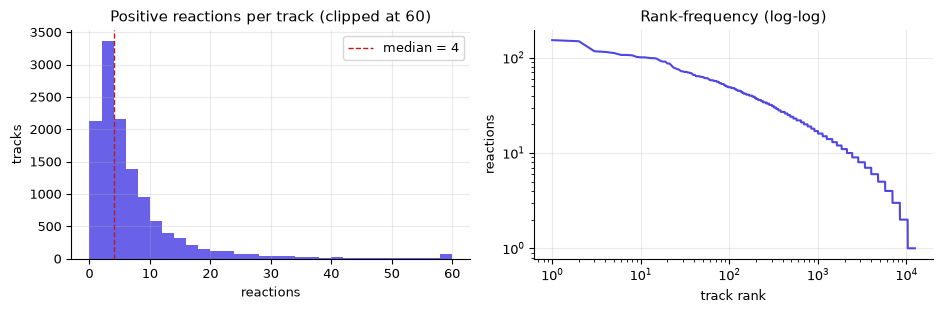

count    12433.0
mean         6.8
std          9.1
min          1.0
25%          2.0
50%          4.0
75%          8.0
90%         15.0
99%         45.0
max        153.0

Tracks with exactly one positive reaction: 2,127 (17.1%)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))

bins = np.arange(0, 61, 2)
axes[0].hist(np.clip(track_pop, 0, 60), bins=bins, color=ACCENT, alpha=0.85)
axes[0].axvline(np.median(track_pop), color=NEGATIVE, linestyle="--", linewidth=1,
                label=f"median = {np.median(track_pop):.0f}")
axes[0].set_title("Positive reactions per track (clipped at 60)")
axes[0].set_xlabel("reactions")
axes[0].set_ylabel("tracks")
axes[0].legend()

ranked = np.sort(track_pop)[::-1]
axes[1].plot(np.arange(1, len(ranked) + 1), ranked, color=ACCENT)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Rank-frequency (log-log)")
axes[1].set_xlabel("track rank")
axes[1].set_ylabel("reactions")

plt.tight_layout()
plt.show()

quantiles = pd.Series(track_pop).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])
print(quantiles.round(1).to_string())
print()
print(f"Tracks with exactly one positive reaction: {(track_pop == 1).sum():,} "
      f"({(track_pop == 1).mean():.1%})")

In [19]:
cumulative = np.cumsum(ranked) / ranked.sum()
share = pd.DataFrame(
    [(f"top {p}%", f"{cumulative[max(0, int(p / 100 * len(ranked)) - 1)]:.1%}")
     for p in (1, 5, 10, 25, 50)],
    columns=["share of tracks", "share of all positive reactions"],
)
share

,share of tracks,share of all positive reactions
0,top 1%,9.6%
1,top 5%,27.0%
2,top 10%,39.9%
3,top 25%,63.3%
4,top 50%,84.4%


## B.3 How concentrated is attention?

The Lorenz curve and its Gini coefficient put a single number on the concentration
above. This is the baseline any recommender should be compared against: an engine that
simply returns the most popular tracks would reproduce this curve exactly, and would
therefore be worthless as a discovery tool no matter how well it scored on accuracy.

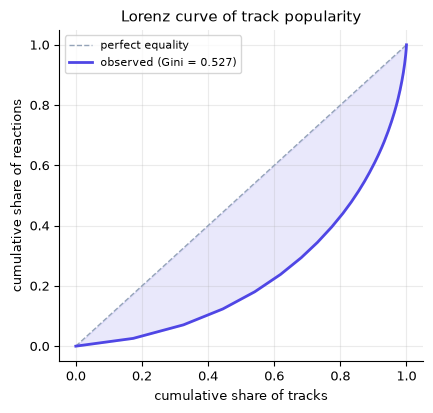

In [20]:
def gini(values):
    arr = np.sort(np.asarray(values, dtype=float))
    n = arr.size
    if n == 0 or arr.sum() == 0:
        return 0.0
    index = np.arange(1, n + 1)
    return float((2 * (index * arr).sum()) / (n * arr.sum()) - (n + 1) / n)


ascending = np.sort(track_pop)
lorenz = np.insert(np.cumsum(ascending) / ascending.sum(), 0, 0)
population = np.linspace(0, 1, len(lorenz))

fig, ax = plt.subplots(figsize=(4.4, 4.2))
ax.plot([0, 1], [0, 1], color=MUTED, linestyle="--", linewidth=1, label="perfect equality")
ax.plot(population, lorenz, color=ACCENT, linewidth=2,
        label=f"observed (Gini = {gini(track_pop):.3f})")
ax.fill_between(population, lorenz, population, color=ACCENT, alpha=0.12)
ax.set_title("Lorenz curve of track popularity")
ax.set_xlabel("cumulative share of tracks")
ax.set_ylabel("cumulative share of reactions")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## B.4 Artist catalogue sizes

The recommendation engine shortlists artists first and then draws tracks from them, so
how many tracks an artist has is not a cosmetic statistic - it decides whether a
shortlisted artist can contribute anything at all.

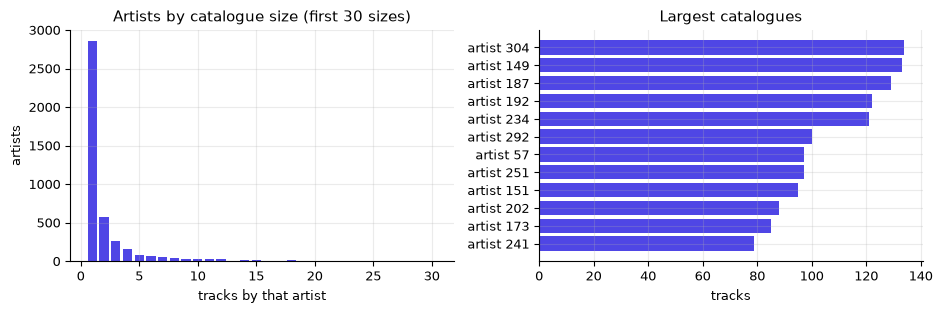

Distinct artists with at least one track: 4,391
Catalogue size - mean 3.26, median 1, 90th pct 6, max 134
Artists with a single track: 2,861 (65.2%)
Artists with 10 or fewer:    4,154 (94.6%)


In [21]:
catalogue = pd.Series(list(track_to_artist.values()))
attributed = catalogue[catalogue != -1]
sizes = attributed.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))

size_counts = sizes.value_counts().sort_index()
axes[0].bar(size_counts.index[:30], size_counts.values[:30], color=ACCENT)
axes[0].set_title("Artists by catalogue size (first 30 sizes)")
axes[0].set_xlabel("tracks by that artist")
axes[0].set_ylabel("artists")

top = sizes.head(12).sort_values()
axes[1].barh([f"artist {a}" for a in top.index], top.values, color=ACCENT)
axes[1].set_title("Largest catalogues")
axes[1].set_xlabel("tracks")

plt.tight_layout()
plt.show()

print(f"Distinct artists with at least one track: {sizes.size:,}")
print(f"Catalogue size - mean {sizes.mean():.2f}, median {sizes.median():.0f}, "
      f"90th pct {sizes.quantile(0.9):.0f}, max {sizes.max()}")
print(f"Artists with a single track: {(sizes == 1).sum():,} ({(sizes == 1).mean():.1%})")
print(f"Artists with 10 or fewer:    {(sizes <= 10).sum():,} ({(sizes <= 10).mean():.1%})")

94.6% of artists have ten tracks or fewer, and the median artist has exactly one. That
distribution is the reason the engine's per-artist candidate cap of ten is close to
inert for most artists - and the reason it matters enormously for the few hundred
artists above it, since those are precisely the artists a heavy listener has already
worked through.

## B.5 Coverage gaps

Three groups of tracks are, for different reasons, invisible or near-invisible to a
pipeline that routes everything through artists. Quantifying them is the point of this
section: each one is a bounded, fixable data problem rather than a modelling limitation.

In [22]:
unattributed = int((catalogue == -1).sum())
no_reactions = n_tracks_total - n_tracks_scored
scored_ids = set(track_id_to_idx)
unattributed_and_scored = sum(
    1 for tid, aid in track_to_artist.items() if aid == -1 and tid in scored_ids
)

gaps = pd.DataFrame(
    [
        ("No artist attribution (artists_id empty or unresolved)", unattributed),
        ("No positive reaction yet", no_reactions),
        ("Unattributed but does have reactions", unattributed_and_scored),
    ],
    columns=["gap", "tracks"],
)
gaps["share of catalogue"] = (gaps["tracks"] / n_tracks_total).map("{:.1%}".format)
gaps["tracks"] = gaps["tracks"].map("{:,}".format)
gaps

,gap,tracks,share of catalogue
0,No artist attribution (artists_id empty or unresolved),529,3.6%
1,No positive reaction yet,"2,410",16.2%
2,Unattributed but does have reactions,409,2.8%


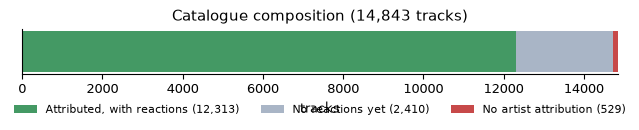

In [23]:
fig, ax = plt.subplots(figsize=(7, 1.8))

attributed_scored = n_tracks_total - unattributed - no_reactions + unattributed_and_scored
segments = [
    ("Attributed, with reactions", attributed_scored, POSITIVE),
    ("No reactions yet", no_reactions, MUTED),
    ("No artist attribution", unattributed, NEGATIVE),
]
left = 0
for label, width, colour in segments:
    ax.barh([0], [width], left=left, color=colour, alpha=0.8, label=f"{label} ({width:,})")
    left += width

ax.set_xlim(0, n_tracks_total)
ax.set_yticks([])
ax.set_xlabel("tracks")
ax.set_title(f"Catalogue composition ({n_tracks_total:,} tracks)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.45), ncol=3, fontsize=8, frameon=False)
ax.grid(False)
plt.tight_layout()
plt.show()

The two groups overlap slightly, so the segments above are drawn disjoint. Read
individually:

- **529 tracks have no artist.** The scraper could not resolve a performer string to a
  known artist. A backfill pass in the engine notebook recovered 176 of 375 flagged
  tracks by exact name match and 4 more by fuzzy match; the remainder are still
  unresolved. Because the engine only proposes candidates through artists, these tracks
  can be reached only by the popularity fallback.
- **2,410 tracks have no positive reaction.** These are new or simply unnoticed uploads.
  They are the tracks a discovery tool exists to surface, and they are also the ones a
  purely collaborative model has nothing to say about - the item cold-start problem in
  its most direct form.
- The two groups overlap by 409 tracks, so together they cover 2,530 tracks - 17.0% of
  the catalogue.

## B.6 Users

The two trained models were built from different signal, so they cover different user
populations: the artist-level model additionally counts artist-message reactions and
uploads, while the track-level model counts only positive track reactions.

In [24]:
artist_only = n_users_artist - n_users_track
print(f"Users in the artist model: {n_users_artist:,}")
print(f"Users in the track model:  {n_users_track:,}")
print(f"Difference:                {artist_only:,}")
print()
print("Users present in the artist model but not the track model can be shortlisted an")
print("artist for, but cannot have their candidates re-ranked - the engine falls back to")
print("popularity within the candidate pool for them.")

Users in the artist model: 1,310
Users in the track model:  1,239
Difference:                71

Users present in the artist model but not the track model can be shortlisted an
artist for, but cannot have their candidates re-ranked - the engine falls back to
popularity within the candidate pool for them.


## B.7 What this means for Chapter 4

Every design decision in the recommendation engine traces back to a measurement above.

| Measurement | Consequence for the engine |
|---|---|
| 0.55% density, median 4 reactions per track | Track-level collaborative filtering alone is unreliable, hence artist-level shortlisting first |
| 17% of tracks have exactly one reaction | Track embeddings in the tail are close to noise; a popularity prior is needed as a tie-breaker |
| Gini 0.53 on track popularity | A popularity-ranked baseline looks strong on accuracy metrics while being useless for discovery, so coverage must be measured alongside accuracy |
| Median artist has one track, 94.6% have <= 10 | A shortlist of N artists yields far fewer than N x 10 candidates; the pool must be able to widen |
| 2,410 tracks with no reactions | Item cold start is not an edge case - it is 16% of the catalogue |
| 529 unattributed tracks | An artist-routed pipeline cannot reach them at all |
| 71 users with artist history but no track history | The re-ranking stage must degrade gracefully rather than assume a track embedding exists |

---

## Summary

**Part A.** Cleaning in this project happens at ingest, not as a batch pass: performer
strings are stripped of brackets, handles and promotional text; artist names are split
on the delimiters uploaders actually use and then normalised (invisible characters,
stray punctuation, a blocklist of non-names, domain-shaped strings, case-insensitive
duplicates); featured artists credited in the title are recovered; untitled tracks are
rejected at the source; and re-shares merge into the existing row rather than
duplicating it. The `reaction_types` table converts raw emoji into a signed
`(sentiment, strength)` feature, which is what makes a weighted per-track score possible
at all - with three rows whose sign contradicts their description, flagged in A.8.

**Part B.** The cleaned catalogue holds 14,843 tracks by 5,107 canonical artists, with
84,795 positive reactions from about 1,300 users - a user-track matrix that is 0.55%
dense, with a Gini coefficient of 0.53 on track popularity, a median of four reactions
per track and a median artist catalogue of one. 17% of the catalogue is either
unattributed or has never been reacted to. These numbers are not incidental context:
they are the direct justification for the two-stage architecture, the candidate-widening
logic and the coverage metrics in Chapter 4.